<a href="https://colab.research.google.com/github/007pushkar/Phone-pay-analysis/blob/main/Phone_pay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/PhonePe/pulse.git

Cloning into 'pulse'...
remote: Enumerating objects: 17904, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 17904 (delta 19), reused 17 (delta 17), pack-reused 17855 (from 2)
Receiving objects: 100% (17904/17904), 26.13 MiB | 14.20 MiB/s, done.
Resolving deltas: 100% (8723/8723), done.
Updating files: 100% (9029/9029), done.
fatal: destination path 'pulse' already exists and is not an empty directory.


In [4]:
import sqlite3
import pandas as pd

In [10]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
conn = sqlite3.connect("phonepe.db")
cursor = conn.cursor()

In [6]:
cursor.execute("""
CREATE TABLE Aggregated_Transaction (
    state TEXT,
    year INTEGER,
    quarter INTEGER,
    transaction_type TEXT,
    transaction_count INTEGER,
    transaction_amount REAL
)
""")

In [7]:
cursor.execute("""
CREATE TABLE Aggregated_User (
    state TEXT,
    year INTEGER,
    quarter INTEGER,
    brand TEXT,
    user_count INTEGER,
    percentage REAL
)
""")

In [8]:
cursor.execute("""
CREATE TABLE Map_Transaction (
    state TEXT,
    year INTEGER,
    quarter INTEGER,
    district TEXT,
    count INTEGER,
    amount REAL
)
""")

In [13]:
path = "/content/pulse/data/aggregated/transaction/country/india/state/"

data = []

for state in os.listdir(path):
    state_path = path + state + "/"

    for year in os.listdir(state_path):
        year_path = state_path + year + "/"

        for file in os.listdir(year_path):
            file_path = year_path + file

            with open(file_path, 'r') as f:
                d = json.load(f)

                for i in d['data']['transactionData']:
                    data.append({
                        "State": state,
                        "Year": int(year),
                        "Quarter": int(file.strip('.json')),
                        "Type": i['name'],
                        "Count": i['paymentInstruments'][0]['count'],
                        "Amount": i['paymentInstruments'][0]['amount']
                    })

df = pd.DataFrame(data)
df.head()

,State,Year,Quarter,Type,Count,Amount
0,madhya-pradesh,2018,1,Recharge & bill payments,4404190,6.670573e+08
1,madhya-pradesh,2018,1,Peer-to-peer payments,2848290,7.590791e+09
2,madhya-pradesh,2018,1,Financial Services,230519,4.337429e+07
3,madhya-pradesh,2018,1,Merchant payments,196394,1.701197e+08
4,madhya-pradesh,2018,1,Others,346002,2.102615e+08


In [14]:
df.to_sql("Aggregated_Transaction", conn, if_exists="replace", index=False)

5034

In [16]:
query = """
SELECT state, SUM(Amount) as total
FROM Aggregated_Transaction
GROUP BY state
ORDER BY total DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
result

,State,total
0,telangana,4.165596e+13
1,karnataka,4.067872e+13
2,maharashtra,4.037420e+13
3,andhra-pradesh,3.466908e+13
4,uttar-pradesh,2.688521e+13
5,rajasthan,2.634324e+13
6,madhya-pradesh,1.912528e+13
7,bihar,1.790135e+13
8,west-bengal,1.558416e+13
9,odisha,1.226398e+13


In [18]:
pd.read_sql("""
SELECT state, SUM(Amount) AS total
FROM Aggregated_Transaction
GROUP BY state
ORDER BY total DESC
LIMIT 10
""", conn)

,State,total
0,telangana,4.165596e+13
1,karnataka,4.067872e+13
2,maharashtra,4.037420e+13
3,andhra-pradesh,3.466908e+13
4,uttar-pradesh,2.688521e+13
5,rajasthan,2.634324e+13
6,madhya-pradesh,1.912528e+13
7,bihar,1.790135e+13
8,west-bengal,1.558416e+13
9,odisha,1.226398e+13


In [20]:
pd.read_sql("""
SELECT year, SUM(Amount) AS total
FROM Aggregated_Transaction
GROUP BY year
ORDER BY year
""", conn)

,Year,total
0,2018,1.623045e+12
1,2019,6.276688e+12
2,2020,1.464116e+13
3,2021,3.459870e+13
4,2022,6.426633e+13
5,2023,9.449181e+13
6,2024,1.296246e+14


In [24]:
pd.read_sql("""
SELECT Type, SUM(Count) AS total
FROM Aggregated_Transaction
GROUP BY Type
ORDER BY total DESC
""", conn)

,Type,total
0,Merchant payments,130238755487
1,Peer-to-peer payments,85032446653
2,Recharge & bill payments,19596755603
3,Others,262050188
4,Financial Services,154208943


In [25]:
from google.colab import files
files.download("phonepe.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##EDA : Exploratory Data Analysis

In [ ]:
import os
import json
import pandas as pd

path = "/content/pulse/data/aggregated/transaction/country/india/state/"

data = []

for state in os.listdir(path):
    for year in os.listdir(path + state):
        for file in os.listdir(path + state + "/" + year):
            with open(path + state + "/" + year + "/" + file) as f:
                d = json.load(f)

                for i in d["data"]["transactionData"]:
                    data.append({
                        "State": state,
                        "Year": int(year),
                        "Quarter": int(file.strip(".json")),
                        "Type": i["name"],
                        "Count": i["paymentInstruments"][0]["count"],
                        "Amount": i["paymentInstruments"][0]["amount"]
                    })

df = pd.DataFrame(data)

In [ ]:
df.isnull().sum()
df.duplicated().sum()

df["State"] = df["State"].str.replace("-", " ").str.title()

In [ ]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   State    5034 non-null   object 
 1   Year     5034 non-null   int64  
 2   Quarter  5034 non-null   int64  
 3   Type     5034 non-null   object 
 4   Count    5034 non-null   int64  
 5   Amount   5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


##Top States

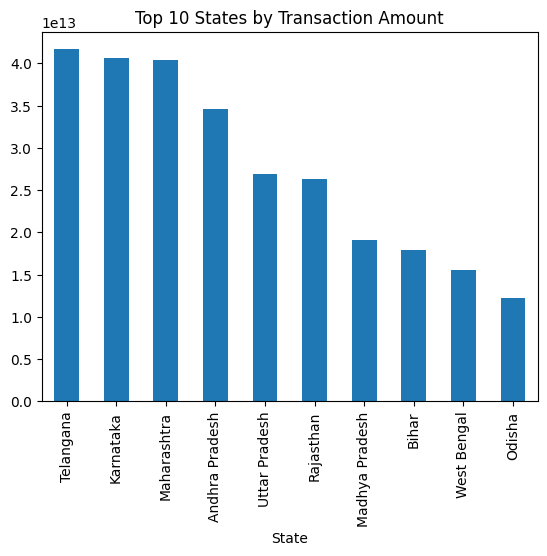

In [ ]:
import matplotlib.pyplot as plt

top_states = df.groupby("State")["Amount"].sum().nlargest(10)

top_states.plot(kind='bar')
plt.title("Top 10 States by Transaction Amount")
plt.show()

##Payment Types

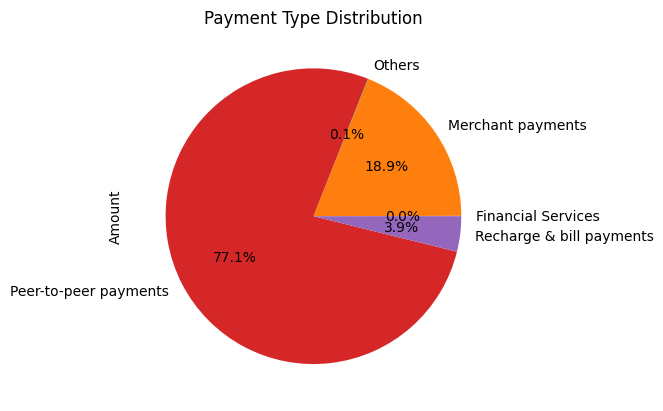

In [ ]:
df.groupby("Type")["Amount"].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Type Distribution")
plt.show()

##Yearly Growth

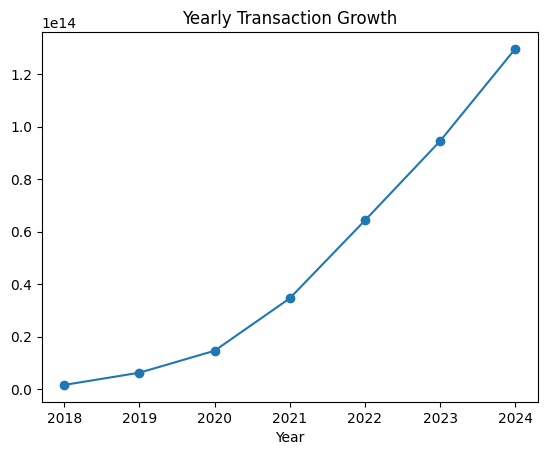

In [ ]:
yearly = df.groupby("Year")["Amount"].sum()

yearly.plot(marker='o')
plt.title("Yearly Transaction Growth")
plt.show()

#Insights

###Digital payments increased sharply after 2020

###Southern states dominate transactions

###Peer-to-peer payments are highest

###Strong correlation between count and amount

#ML (Machine Learning)
##Predict:
##👉 Transaction Amount OR Count

In [ ]:
df_ml = df.copy()

# Convert categorical
df_ml = pd.get_dummies(df_ml, columns=["State", "Type"], drop_first=True)

X = df_ml.drop(["Amount"], axis=1)
y = df_ml["Amount"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Linear Regression:")
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

print("Random Forest:")
print(mean_absolute_error(y_test, y_pred_rf))
print(r2_score(y_test, y_pred_rf))

Linear Regression:
83036845843.34311
0.5734045560888976
Random Forest:
5647861567.172938
0.9896539098384622


<Axes: >

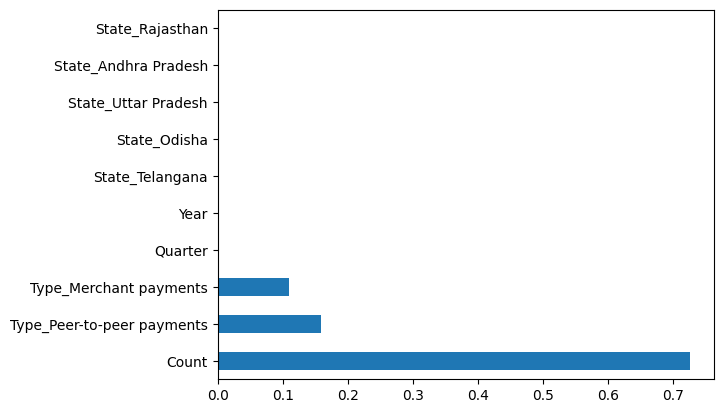

In [ ]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')

#ML Insights

###Random Forest performs better than LinearRegression

###State and transaction type heavily influence amount

###Year shows strong upward trend

In [ ]:
import joblib
joblib.dump(rf, "model.pkl")

['model.pkl']

In [ ]:
import os
import json
import pandas as pd

path = "/content/pulse/data/aggregated/transaction/country/india/state/"

data = []

for state in os.listdir(path):
    for year in os.listdir(path + state):
        for file in os.listdir(path + state + "/" + year):
            try:
                with open(path + state + "/" + year + "/" + file) as f:
                    d = json.load(f)

                    if d["data"] and d["data"]["transactionData"]:
                        for i in d["data"]["transactionData"]:
                            data.append({
                                "State": state.replace("-", " ").title(),
                                "Year": int(year),
                                "Quarter": int(file.strip(".json")),
                                "Type": i["name"],
                                "Count": i["paymentInstruments"][0]["count"],
                                "Amount": i["paymentInstruments"][0]["amount"]
                            })
            except:
                pass

df = pd.DataFrame(data)

# Save CSV
df.to_csv("data.csv", index=False)

print("✅ data.csv created")

✅ data.csv created


In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="PhonePe Dashboard", layout="wide")

# Load data
@st.cache_data
def load_data():
    return pd.read_csv("data.csv")

df = load_data()

# Title
st.title("📊 PhonePe Transaction Dashboard")

# Sidebar filters
st.sidebar.header("Filters")

state = st.sidebar.selectbox("Select State", df["State"].unique())
year = st.sidebar.selectbox("Select Year", sorted(df["Year"].unique()))
quarter = st.sidebar.selectbox("Select Quarter", sorted(df["Quarter"].unique()))

# Filter data
filtered = df[
    (df["State"] == state) &
    (df["Year"] == year) &
    (df["Quarter"] == quarter)
]

# Metrics
col1, col2 = st.columns(2)

col1.metric("Total Transactions", int(filtered["Count"].sum()))
col2.metric("Total Amount (₹)", int(filtered["Amount"].sum()))

# Bar Chart
st.subheader("💳 Transaction by Type")

type_data = filtered.groupby("Type")["Amount"].sum().reset_index()

fig = px.bar(type_data, x="Type", y="Amount", color="Type")
st.plotly_chart(fig, use_container_width=True)

# Trend Chart
st.subheader("📈 Yearly Trend")

trend = df[df["State"] == state].groupby("Year")["Amount"].sum().reset_index()

fig2 = px.line(trend, x="Year", y="Amount", markers=True)
st.plotly_chart(fig2, use_container_width=True)

# Raw Data Button
if st.button("Show Raw Data"):
    st.dataframe(filtered)

# Download Button
csv = filtered.to_csv(index=False).encode("utf-8")
st.download_button("Download Data", csv, "filtered_data.csv")

# Insights Section
st.subheader("📌 Insights")

st.write("• Digital payments are increasing every year")
st.write("• Some states dominate transaction volume")
st.write("• P2P transactions are widely used")

2026-04-29 13:52:52.350 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 13:52:52.358 No runtime found, using MemoryCacheStorageManager
2026-04-29 13:52:52.373 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 13:52:52.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 13:52:52.379 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 13:52:52.384 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 13:52:52.389 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 13:52:52.391 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 13:52:52.403 Thread 'MainThread':